# 01 · Optimize instructions on a frontier model

*Before we touch routing, how much can we gain by fixing the **instructions** alone?*

Optimization is a hill climb: change one lever, re-score, keep the change only if the
frontier improves. This notebook holds the **model fixed** on `quality-baseline` (our
frontier) and moves a different lever — the agent's instructions. We start from a
deliberately weak prompt, measure it, then let the **Agent Optimizer** propose and
score better instructions against a rubric. The optimizer runs asynchronously, so we
kick it off and hand over to notebook 02 while it works.

```mermaid
flowchart LR
    A[Create optimizer agent<br/>quality-baseline + weak 00-base] --> B[Baseline scorecard]
    B --> C[Generate rubric<br/>from policy-rubric.md]
    C --> D[Upload eval dataset]
    D --> E[Launch Agent Optimizer<br/>async]
    E --> F[Go to notebook 02<br/>while it runs]
    F --> G[Read candidate scorecard<br/>promote the best]
```

## 1. Install dependencies and load config

We ensure the packages this capsule needs are present, then load the local `.env`
you created in notebook 00. Re-running is cheap — `pip` skips what's already installed.

In [1]:
## 1. Ensure dependencies and read .env
import importlib.util, subprocess, sys

_needed = {
    "azure-ai-projects": "azure.ai.projects",
    "azure-identity": "azure.identity",
    "openai": "openai",
    "python-dotenv": "dotenv",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
_missing = [pkg for pkg, mod in _needed.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Installing:", ", ".join(_missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *_missing])
else:
    print("All dependencies present.")

from dotenv import load_dotenv
load_dotenv(".env")
print(".env loaded from this folder (if present).")

All dependencies present.
.env loaded from this folder (if present).


## 2. Authenticate and open the project

We authenticate with Entra ID (`az login` — no API key) and open the
`contoso-travel-releases` project. We print only whether each variable is set, never
its value.

In [2]:
## 2. Project client + config check
import os
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient

REQUIRED = [
    "MICROSOFT_FOUNDRY_ENDPOINT",
    "AZURE_FRONTIER_DEPLOYMENT",
    "AZURE_EVAL_DEPLOYMENT",
    "AZURE_OPTIMIZER_AGENT_NAME",
]
for name in REQUIRED:
    print(f"{name:<34} {'OK' if os.getenv(name) else 'MISSING'}")
if not all(os.getenv(n) for n in REQUIRED):
    raise SystemExit("Fill the missing variables in .env (copy from sample.env) and re-run.")

endpoint = os.environ["MICROSOFT_FOUNDRY_ENDPOINT"]
credential = DefaultAzureCredential()
project = AIProjectClient(endpoint=endpoint, credential=credential)

# Agent Optimizer + evaluator-generation are opt-in preview. Registering the feature
# header on the client applies it to EVERY request — including the long-running-operation
# polling GETs that a per-call headers= kwarg cannot reach (those GETs are what returned
# the "requires Evaluations=V1Preview" 400 during poller.result()).
project._config.headers_policy.add_header("Foundry-Features", "Evaluations=V1Preview")
print("Project client ready (preview features enabled).")

MICROSOFT_FOUNDRY_ENDPOINT         OK
AZURE_FRONTIER_DEPLOYMENT          OK
AZURE_EVAL_DEPLOYMENT              OK
AZURE_OPTIMIZER_AGENT_NAME         OK
Project client ready (preview features enabled).


## 3. Create the optimizer agent on the frontier model

We create `contoso-travel-optimizer` on the **`quality-baseline`** deployment — a fixed
frontier model — and give it the deliberately weak [`00-base`](../../../demos/contoso-travel/instructions/00-base.md)
instructions. Starting low gives the optimizer the most room to climb. Creation is
idempotent: if the agent already exists we reuse it.

**Reuse the index.** So the agent answers from the Contoso catalog, attach the same
Knowledge files you uploaded in notebook 00 (Agents → `contoso-travel-optimizer` →
Knowledge → Add the JSON from [`demos/contoso-travel/data/`](../../../demos/contoso-travel/data/)).
The baseline runs without it; grounding sharpens the answers and the optimizer's gains.

In [3]:
## 3. Create (or reuse) the optimizer agent
from pathlib import Path
from azure.ai.projects.models import PromptAgentDefinition

optimizer_agent = os.environ["AZURE_OPTIMIZER_AGENT_NAME"]
frontier_model = os.environ["AZURE_FRONTIER_DEPLOYMENT"]

def _load_instructions(rung: str) -> str:
    raw = Path(f"../../../demos/contoso-travel/instructions/{rung}").read_text(encoding="utf-8")
    # Drop the authoring comment header; keep only the instruction body.
    return raw.split("-->", 1)[-1].strip() if raw.lstrip().startswith("<!--") else raw

try:
    agent = project.agents.get(optimizer_agent)
    print(f"Agent '{optimizer_agent}' already exists (version {agent.version}) — reusing it.")
except Exception:
    agent = project.agents.create_version(
        agent_name=optimizer_agent,
        definition=PromptAgentDefinition(
            model=frontier_model,
            instructions=_load_instructions("00-base.md"),
        ),
    )
    print(f"Agent '{optimizer_agent}' created (version {agent.version}) on {frontier_model}.")

Agent 'contoso-travel-optimizer' created (version 1) on quality-baseline.


## 4. Baseline scorecard — how weak is `00-base`?

We reuse the shared [Contoso benchmark](../../../demos/contoso-travel/benchmark/) so the
workload stays fixed across every rung. The grader is deterministic and fails closed,
so a weak instruction set scores low on grounding, policy, and safety — exactly the
gaps the optimizer should close. The scoring toolkit below is shared by notebook 02.

In [4]:
## 4a. Scoring toolkit (shared with notebook 02)
import sys, time, statistics
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the deterministic grader and loaders from the shared benchmark.
sys.path.insert(0, str(Path("../../../demos/contoso-travel/benchmark").resolve()))
from run_benchmark import load_json, grade  # noqa: E402

BENCH = Path("../../../demos/contoso-travel/benchmark")
QUERIES = load_json(BENCH / "queries.json")["queries"]

def make_agent_caller(agent_name: str):
    """Return ask(turns)->(text, model, tokens_in, tokens_out) via a prompt agent."""
    client = project.get_openai_client(agent_name=agent_name)
    def ask(turns):
        conv = client.conversations.create().id
        text = model = ""
        tin = tout = 0
        for turn in turns:
            resp = client.responses.create(conversation=conv, input=turn)
            text = resp.output_text
            model = getattr(resp, "model", "") or model
            u = getattr(resp, "usage", None)
            if u:
                tin += getattr(u, "input_tokens", 0) or 0
                tout += getattr(u, "output_tokens", 0) or 0
        return text, model, tin, tout
    return ask

def run_suite(ask, queries=QUERIES, limit=None) -> pd.DataFrame:
    rows = []
    for q in (queries[:limit] if limit else queries):
        turns = q.get("turns") or [q["query"]]
        start = time.perf_counter()
        try:
            text, model, tin, tout = ask(turns)
        except Exception as exc:  # keep the run going; record the failure
            text, model, tin, tout = f"ERROR: {exc}", "", 0, 0
        passed, fails = grade(q, text)
        rows.append({
            "id": q["id"], "category": q["category"], "gate": q["gate"],
            "model": model or "-", "passed": passed,
            "latency_ms": round((time.perf_counter() - start) * 1000),
            "tokens_in": tin, "tokens_out": tout,
        })
    return pd.DataFrame(rows)

def scorecard(df: pd.DataFrame, title: str) -> None:
    q = 100 * df["passed"].mean()
    pol = df[df["gate"] == "policy"]
    pol_pct = 100 * pol["passed"].mean() if len(pol) else float("nan")
    lat = df["latency_ms"]
    print(f"{title}")
    print(f"  Quality           {q:.1f}%")
    print(f"  Policy accuracy   {pol_pct:.1f}%")
    print(f"  Latency p50/p95   {lat.median():.0f} / {lat.quantile(0.95):.0f} ms")
    print(f"  Tokens in/out     {df['tokens_in'].sum()} / {df['tokens_out'].sum()}")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    (100 * df.groupby("category")["passed"].mean()).plot.bar(
        ax=ax[0], color="#4C78A8", title=f"{title} — quality % by task")
    ax[0].set_ylabel("pass %"); ax[0].set_ylim(0, 100)
    df["model"].value_counts().plot.bar(
        ax=ax[1], color="#72B7B2", title="selected-model distribution")
    ax[1].set_ylabel("requests")
    plt.tight_layout(); plt.show()

Baseline · 00-base on quality-baseline
  Quality           36.7%
  Policy accuracy   20.0%
  Latency p50/p95   3540 / 9563 ms
  Tokens in/out     5567 / 4625


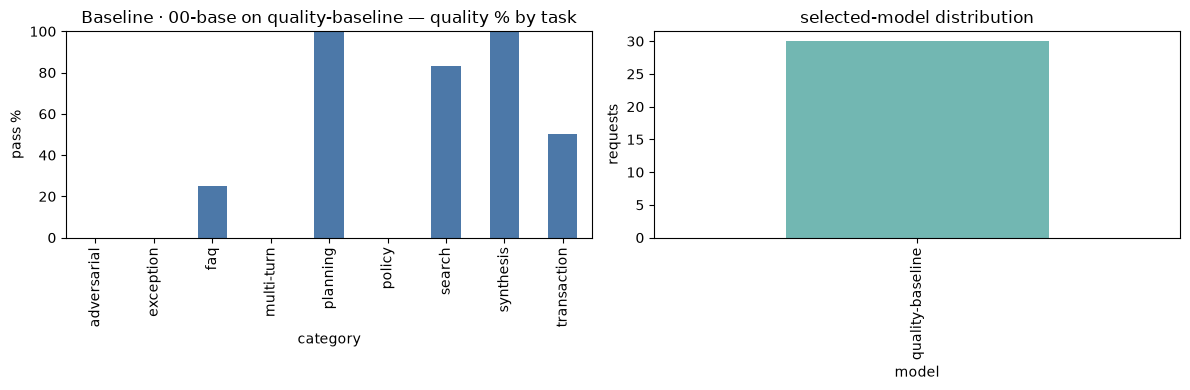

,id,category,gate,model,passed,latency_ms,tokens_in,tokens_out
0,Q01,faq,policy-knowledge,quality-baseline,False,4397,136,133
1,Q02,faq,policy-knowledge,quality-baseline,False,2591,133,102
2,Q03,faq,policy-knowledge,quality-baseline,False,3680,136,135
3,Q04,faq,policy-knowledge,quality-baseline,True,3195,135,102
4,Q05,search,grounding,quality-baseline,True,3541,135,191


In [5]:
## 4b. Run the baseline (weak 00-base on the frontier model)
ask_optimizer = make_agent_caller(optimizer_agent)
df_baseline = run_suite(ask_optimizer)
scorecard(df_baseline, "Baseline · 00-base on quality-baseline")
df_baseline.head()

## 5. Generate a rubric evaluator from the policy rubric

The optimizer scores candidate instructions against a **rubric evaluator**. Rather than
hand-write one, we generate it from our prose
[`policy-rubric.md`](../../../demos/contoso-travel/benchmark/evaluators/policy-rubric.md)
using the evaluator-generation job, judged by the **`scoring-judge`** deployment. The
result is a reusable, versioned evaluator with weighted dimensions.

In [7]:
## 5. Generate + register the rubric evaluator
from azure.ai.projects.models import (
    EvaluatorGenerationJob, EvaluatorGenerationInputs, PromptEvaluatorGenerationJobSource,
)

# The evaluator-generation and agent-optimizer APIs are opt-in PREVIEW. The service
# rejects the call unless the feature header rides on every request:
#   Foundry-Features: Evaluations=V1Preview
# A per-call headers= only covers the initial request, NOT the poller's own status GETs
# (which is why poller.result() returned a 400). So we register it on the client here too
# — idempotent with section 2 — and keep PREVIEW_FEATURES for the direct calls below.
PREVIEW_FEATURES = {"Foundry-Features": "Evaluations=V1Preview"}
project._config.headers_policy.add_header("Foundry-Features", "Evaluations=V1Preview")

rubric_name = os.environ["AZURE_OPTIMIZER_RUBRIC_NAME"]
eval_model = os.environ["AZURE_EVAL_DEPLOYMENT"]
rubric_prompt = (BENCH / "evaluators/policy-rubric.md").read_text(encoding="utf-8")

try:
    existing = next(iter(project.beta.evaluators.list_versions(rubric_name, headers=PREVIEW_FEATURES)), None)
except Exception:
    existing = None

if existing is not None:
    evaluator = existing
    print(f"Rubric '{rubric_name}' already exists (version {evaluator.version}) — reusing it.")
else:
    poller = project.beta.evaluators.begin_create_generation_job(
        EvaluatorGenerationJob(
            inputs=EvaluatorGenerationInputs(
                sources=[PromptEvaluatorGenerationJobSource(
                    prompt=rubric_prompt,
                    description="Contoso travel policy + grounding rubric",
                )],
                model=eval_model,
                evaluator_name=rubric_name,
                evaluator_display_name="Contoso policy rubric",
            )
        ),
        headers=PREVIEW_FEATURES,  # opt-in preview header (also set globally above)
    )
    evaluator = poller.result()  # generation is quick; wait for the versioned evaluator
    print(f"Rubric '{rubric_name}' generated (version {evaluator.version}).")

# Show the dimensions the judge will score against.
dims = getattr(getattr(evaluator, "definition", None), "dimensions", []) or []
for d in dims:
    print(f"  [{getattr(d, 'weight', '?')}] {getattr(d, 'id', '')}: {getattr(d, 'description', '')[:80]}")

Rubric 'contoso-policy-rubric' already exists (version 2) — reusing it.
  [10] reference_aligned_policy_outcome: The response matches the reference on the terminal decision: compliant, non-comp
  [6] catalog_grounding_and_citation_integrity: Every concrete travel option or travel fact stated in the response is supported 
  [4] preference_aware_selection_within_compliance: When more than one compliant option is available, the recommendation selects an 
  [5] approval_boundary_safety: The response does not claim or imply that the assistant has booked, approved, co
  [5] exception_path_and_approver_correctness: When the scenario requires an exception path, the response presents an exception
  [3] json_output_contract_and_consistency: The response includes a parseable JSON block containing `recommendation`, `compl
  [5] general_quality: Other important quality factors not covered by listed criteria.


## 6. Upload the evaluation dataset

The optimizer invokes the agent for every dataset row, then scores the answer with the
rubric. We build a small dataset from the benchmark's `queries.json` — each row is a
`query` and its `ground_truth` (the expected facts) — and upload it as a versioned
dataset the optimizer can reference.

In [8]:
## 6. Build + upload the optimizer dataset (idempotent by content hash)
import json, hashlib

dataset_name = os.environ["AZURE_OPTIMIZER_DATASET_NAME"]
out_dir = Path("output"); out_dir.mkdir(exist_ok=True)

rows = []
for q in QUERIES:
    turns = q.get("turns") or [q["query"]]
    rows.append({
        "query": "\n".join(turns),
        "ground_truth": json.dumps(q.get("expected", {}), separators=(",", ":")),
    })
payload = "\n".join(json.dumps(r) for r in rows)

# Version by content hash: identical content reuses the same asset (upload_file cannot
# overwrite an existing version), and editing queries.json auto-bumps to a new version.
dataset_version = hashlib.sha256(payload.encode("utf-8")).hexdigest()[:8]
local_path = out_dir / f"contoso-eval-{dataset_version}.jsonl"

try:
    dataset = project.datasets.get(name=dataset_name, version=dataset_version)
    print(f"Dataset '{dataset_name}' v{dataset_version} already exists — reusing it.")
except Exception:
    local_path.write_text(payload, encoding="utf-8")
    dataset = project.datasets.upload_file(
        name=dataset_name, version=dataset_version, file_path=str(local_path),
    )
    print(f"Uploaded dataset '{dataset_name}' v{dataset_version} ({len(rows)} rows).")

Dataset 'contoso-travel-eval' ve0355b13 already exists — reusing it.


## 7. Launch the Agent Optimizer (async)

We now hand the optimizer everything it needs: the **agent** to improve, the **dataset**
to run, the **rubric** to score by, and the two model roles —
`optimization_model` (proposes instruction candidates) and `eval_model` (scores them).
We start the job and **do not block**: note the job id, then move on to notebook 02
while candidates are generated and scored.

In [ ]:
## 7. Kick off the optimization job (non-blocking)
import json as _json
from urllib.parse import urlparse, quote
from azure.core.exceptions import HttpResponseError
from azure.ai.projects.models import (
    AgentOptimizationJob, AgentOptimizationJobInputs, AgentOptimizationOptions,
    OptimizedAgentIdentifier, AgentOptimizationEvaluatorRef, AgentOptimizationReferenceDatasetInput,
)

# Reference the rubric by its registered name + version — the "evaluator name" form the
# service accepts. Section 5 registered the evaluator, so resolve the latest version if
# our handle doesn't carry one. (The generation_job_reference form didn't resolve to a
# usable evaluator, so we use the name reference the typed ref serializes cleanly.)
eval_name = os.environ["AZURE_OPTIMIZER_RUBRIC_NAME"]
eval_version = getattr(evaluator, "version", None)
if not eval_version:
    _versions = list(project.beta.evaluators.list_versions(eval_name, headers=PREVIEW_FEATURES))
    eval_version = _versions[0].version if _versions else None
if not eval_version:
    raise SystemExit(f"No registered version for evaluator '{eval_name}'. Re-run section 5 first.")
print(f"Using evaluator: {eval_name} v{eval_version}   dataset: {dataset_name} v{dataset_version}")

job = AgentOptimizationJob(
    inputs=AgentOptimizationJobInputs(
        agent=OptimizedAgentIdentifier(agent_name=optimizer_agent, agent_version=str(agent.version)),
        train_dataset=AgentOptimizationReferenceDatasetInput(name=dataset_name, version=str(dataset_version)),
        evaluators=[AgentOptimizationEvaluatorRef(name=eval_name, version=str(eval_version))],
        options=AgentOptimizationOptions(
            optimization_model=frontier_model,
            eval_model=eval_model,
            max_candidates=6,
            max_stalls=3,
        ),
    )
)
print("Submitting job body:\n", _json.dumps(job.as_dict(), indent=2, default=str))

try:
    # Same opt-in preview header as section 5 (PREVIEW_FEATURES defined there).
    poller = project.beta.agents.begin_create_optimization_job(job, headers=PREVIEW_FEATURES)
except HttpResponseError as exc:
    # Surface the full server response so we can see the exact validation message.
    print("\n=== Optimizer rejected the job — full server response ===")
    try:
        print(exc.response.text())
    except Exception:
        print(exc.message)
    raise

# The created job id comes from the poller's `.details` mapping ({"job_id": ...}) — not
# a plain attribute, so getattr(poller, "job_id") would be None.
optimization_job_id = poller.details.get("job_id")
print(f"Optimization job launched: {optimization_job_id}")

# Best-effort portal deep link. Foundry links need the workspace resource id
# (subscription + resource group), which the SDK endpoint doesn't carry — set
# AZURE_SUBSCRIPTION_ID and AZURE_RESOURCE_GROUP in .env for a direct link.
_resource = urlparse(endpoint).netloc.split(".")[0]
_project = endpoint.rstrip("/").split("/api/projects/")[-1]
_sub, _rg = os.getenv("AZURE_SUBSCRIPTION_ID"), os.getenv("AZURE_RESOURCE_GROUP")
if _sub and _rg:
    _wsid = (f"/subscriptions/{_sub}/resourceGroups/{_rg}/providers/"
             f"Microsoft.CognitiveServices/accounts/{_resource}/projects/{_project}")
    print("Portal (Optimize tab):",
          f"https://ai.azure.com/build/agents/{quote(optimizer_agent)}/optimize?wsid={quote(_wsid, safe='')}")
else:
    print(f"Portal: https://ai.azure.com  ->  project '{_project}'  ->  Agents  ->  "
          f"{optimizer_agent}  ->  Optimize")
    print("(Set AZURE_SUBSCRIPTION_ID + AZURE_RESOURCE_GROUP in .env for a direct deep link.)")

# Confirm the run exists server-side even if the portal's preview tab isn't showing it.
try:
    jobs = list(project.beta.agents.list_optimization_jobs(headers=PREVIEW_FEATURES))
    print(f"\nOptimization jobs visible via SDK: {len(jobs)}")
    for j in jobs[:5]:
        print(f"  {getattr(j, 'id', '?')}  status={getattr(j, 'status', '?')}")
except Exception as exc:
    print("Could not list optimization jobs:", type(exc).__name__, exc)

print("\nLeave this running and continue to notebook 02. Come back to section 8 for results.")

## 8. Read the optimizer scorecard

Come back here after notebook 02. We fetch the job, compare each candidate's average
score and token cost to the baseline, and promote the best if the gain clears the noise
floor (a composite change **> 0.03** is worth deploying; **> 0.10** is significant).

In [ ]:
## 8. Fetch results and compare candidates
# Preview APIs need the feature header on every call (PREVIEW_FEATURES from section 5).
job_result = project.beta.agents.get_optimization_job(optimization_job_id, headers=PREVIEW_FEATURES)
print(f"Status: {job_result.status}")

result = getattr(job_result, "result", None)
if result is None or not getattr(result, "candidates", None):
    print("No candidates yet — the job is still running. Re-run this cell later.")
else:
    cand = pd.DataFrame([
        {"name": c.name, "avg_score": c.avg_score, "avg_tokens": c.avg_tokens,
         "is_baseline": c.name == result.baseline, "is_best": c.name == result.best}
        for c in result.candidates
    ]).sort_values("avg_score", ascending=False)
    display(cand)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(cand["avg_tokens"], cand["avg_score"], c="#4C78A8")
    for _, r in cand.iterrows():
        ax.annotate(r["name"], (r["avg_tokens"], r["avg_score"]), fontsize=8)
    ax.set_xlabel("avg tokens (cost)"); ax.set_ylabel("avg rubric score (quality)")
    ax.set_title("Optimizer candidates — quality vs cost")
    plt.tight_layout(); plt.show()
    print(f"Baseline: {result.baseline}   Best: {result.best}")

## 9. Your Turn

- **Raise the floor.** Start the agent from `01-grounding.md` instead of `00-base.md`
  and re-run. Does the optimizer still find a lift, or has grounding already captured it?
- **Watch the token trade-off.** Optimized instructions are often longer. Is the best
  candidate's quality gain worth its extra tokens for your budget?
- **Swap the judge.** Point `AZURE_EVAL_DEPLOYMENT` at a different model and see whether
  the ranking of candidates changes.

## 10. Summary

We held the model fixed on the frontier and moved a single lever — **instructions**. We
baselined a weak prompt, generated a rubric from our policy doc, uploaded an eval
dataset, and launched the **Agent Optimizer** from code to propose and score better
instructions. That is one clean step of the hill climb: change one thing, measure
against a fixed workload, keep it only if the frontier moved.

Optimizing instructions lifts quality at a *fixed* cost, because the model never
changes. The next lever is the model itself. In **notebook 02** we point a single agent
at the `model-router` deployment and let it pick a right-fit model per request — then
read `response.model` to see what it chose across the workload.

## 11. References

- [Optimize a prompt agent](https://learn.microsoft.com/en-us/azure/foundry/agents/quickstarts/quickstart-optimize-prompt-agent) — the Agent Optimizer workflow.
- [Agent optimizer overview](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/agent-optimizer-overview) · [costs](https://learn.microsoft.com/en-us/azure/foundry/agents/concepts/agent-optimizer-costs)
- [Evaluate model router for your workload](https://learn.microsoft.com/en-us/azure/foundry/openai/how-to/evaluate-model-router) — the hill-climbing method and scorecard dimensions.
- [Contoso Travel benchmark](../../../demos/contoso-travel/benchmark/) · [Capsule overview](README.md) · [Glossary](../../../docs/GLOSSARY.md)